## Upload Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive (1).zip


# Extract ZIP

In [3]:
import zipfile
import os

zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/Dataset')

print("Dataset extracted successfully!")

Dataset extracted successfully!


# Define Paths & Classes

In [4]:
for root, dirs, files in os.walk('/content/Dataset'):
    print(root)

/content/Dataset
/content/Dataset/Combined Dataset
/content/Dataset/Combined Dataset/train
/content/Dataset/Combined Dataset/train/Mild Impairment
/content/Dataset/Combined Dataset/train/Very Mild Impairment
/content/Dataset/Combined Dataset/train/Moderate Impairment
/content/Dataset/Combined Dataset/train/No Impairment
/content/Dataset/Combined Dataset/test
/content/Dataset/Combined Dataset/test/Mild Impairment
/content/Dataset/Combined Dataset/test/Very Mild Impairment
/content/Dataset/Combined Dataset/test/Moderate Impairment
/content/Dataset/Combined Dataset/test/No Impairment


In [5]:
train_path = '/content/Dataset/Combined Dataset/train'
test_path = '/content/Dataset/Combined Dataset/test'

In [6]:
import os

classes = os.listdir(train_path)
print("Detected Classes:", classes)

Detected Classes: ['Mild Impairment', 'Very Mild Impairment', 'Moderate Impairment', 'No Impairment']


# Load and preprocess data

In [7]:
import cv2
import numpy as np

img_size = 128

X_train, y_train = [], []
X_test, y_test = [], []

# Load Training Data
for i, category in enumerate(classes):
    folder_path = os.path.join(train_path, category)

    for img in os.listdir(folder_path):
        try:
            img_path = os.path.join(folder_path, img)
            image = cv2.imread(img_path)
            image = cv2.resize(image, (img_size, img_size))

            X_train.append(image)
            y_train.append(i)
        except:
            pass

# Load Testing Data
for i, category in enumerate(classes):
    folder_path = os.path.join(test_path, category)

    for img in os.listdir(folder_path):
        try:
            img_path = os.path.join(folder_path, img)
            image = cv2.imread(img_path)
            image = cv2.resize(image, (img_size, img_size))

            X_test.append(image)
            y_test.append(i)
        except:
            pass

# Convert to NumPy arrays
X_train = np.array(X_train) / 255.0
X_test = np.array(X_test) / 255.0
y_train = np.array(y_train)
y_test = np.array(y_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (10240, 128, 128, 3)
Test shape: (1279, 128, 128, 3)


# One Hot Encoding

In [8]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=len(classes))
y_test = to_categorical(y_test, num_classes=len(classes))

# Build CNN Model

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(len(classes), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

# Train Model

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 213s 660ms/step - accuracy: 0.6200 - loss: 0.8223 - val_accuracy: 0.5747 - val_loss: 0.8090
Epoch 2/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 218s 681ms/step - accuracy: 0.7878 - loss: 0.4691 - val_accuracy: 0.6474 - val_loss: 0.7612
Epoch 3/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 257s 665ms/step - accuracy: 0.8324 - loss: 0.3780 - val_accuracy: 0.7404 - val_loss: 0.5668
Epoch 4/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 213s 667ms/step - accuracy: 0.8756 - loss: 0.2844 - val_accuracy: 0.8530 - val_loss: 0.3690
Epoch 5/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 205s 639ms/step - accuracy: 0.9026 - loss: 0.2289 - val_accuracy: 0.8796 - val_loss: 0.3125
Epoch 6/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 214s 669ms/step - accuracy: 0.9246 - loss: 0.1836 - val_accuracy: 0.9249 - val_loss: 0.1956
Epoch 7/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 258s 656ms/step - accuracy: 0.9389 - loss: 0.1393 - val_accuracy: 0.9109 - val_loss: 0.2162
Epoch 8/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 262s 657ms/step - accuracy: 0.9438 -

# Evaluate Model

In [11]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 180ms/step - accuracy: 0.9586 - loss: 0.1163
Test Accuracy: 0.958561360836029


# Plot Accuracy Graph

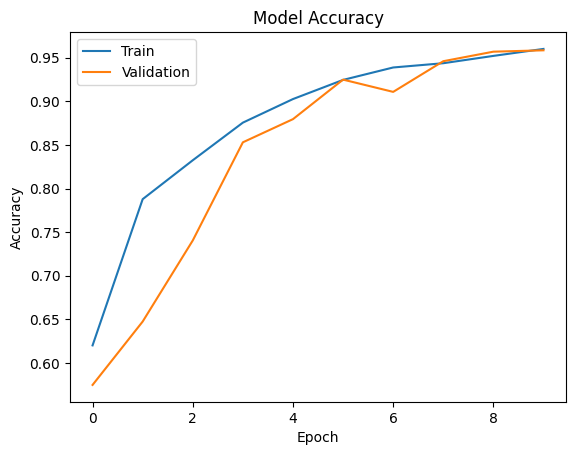

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred_classes))
print("\nClassification Report:\n", classification_report(y_true, y_pred_classes, target_names=classes))

40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 289ms/step
Confusion Matrix:
 [[167   8   0   4]
 [  1 415   0  32]
 [  0   0  12   0]
 [  0   8   0 632]]

Classification Report:
                       precision    recall  f1-score   support

     Mild Impairment       0.99      0.93      0.96       179
Very Mild Impairment       0.96      0.93      0.94       448
 Moderate Impairment       1.00      1.00      1.00        12
       No Impairment       0.95      0.99      0.97       640

            accuracy                           0.96      1279
           macro avg       0.98      0.96      0.97      1279
        weighted avg       0.96      0.96      0.96      1279



In [14]:
model.save("alzheimers_model.h5")

In [16]:
import os
os.listdir('/content')

['.config',
 'Dataset',
 'archive.zip',
 'alzheimers_model.h5',
 'archive (1).zip',
 'sample_data']

In [19]:
from google.colab import drive
drive.mount('/content/drive')

model.save('/content/drive/MyDrive/alzheimers_model.keras')

Mounted at /content/drive
